# **🦠 Anomaly Detection Models**

Isolation Forest

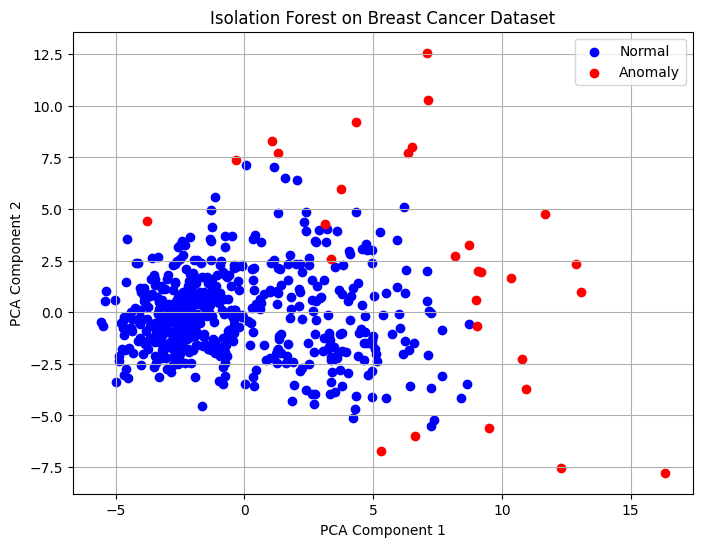

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)

# 2. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply Isolation Forest
clf = IsolationForest(contamination=0.05, random_state=42)
clf.fit(X_scaled)
y_pred = clf.predict(X_scaled)  # -1 = anomaly, 1 = normal

# 4. (Optional) Reduce to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# 5. Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[y_pred == 1, 0], X_2d[y_pred == 1, 1], c='blue', label='Normal')
plt.scatter(X_2d[y_pred == -1, 0], X_2d[y_pred == -1, 1], c='red', label='Anomaly')
plt.title("Isolation Forest on Breast Cancer Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()